In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_pure_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12 / 12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source (Mojito light EMRI_G, matches paris5_lhs_box_brute.py)
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
               Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist,
              np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')
print(f'SNR (rhostat): {float(gwf.SNR(gwf.freq_wave(loglike_obj.signal))):.4f}')


def log_density(params):
    """
    Coherent (pure) f-statistic (loglike_pure_noise.LogLike), row-by-row,
    over the 12-dim brute parameter space
    [logm1, logm2, a, p0, e0, dist, cosqS, phiS, cosqK, phiK, Phi_phi0, Phi_r0].
    xI0 and Phi_theta0 are held fixed at the injected values.
    """
    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        (logm1, logm2, a_i, p0_i, e0_i, dist_i,
         cos_qS_i, phiS_i, cos_qK_i, phiK_i, Phi_phi0_i, Phi_r0_i) = params[i]
        try:
            qS_i = np.arccos(cos_qS_i)
            qK_i = np.arccos(cos_qK_i)
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist_i, qS_i, phiS_i, qK_i, phiK_i,
                Phi_phi0_i, Phi_theta0, Phi_r0_i,
            ]
            out[i] = float(loglike_obj(theta))
        except Exception:
            pass
    return out


def prior_transform(u):
    # matches paris5_lhs_box_brute.py box (nsigma=2 for all params except
    # e0 and phir0, which get 6sigma)
    logm1lim   = [5.82615, 5.83032]
    logm2lim   = [1.99273, 1.99370]
    alim       = [0.49650, 0.50850]
    p0lim      = [15.64820, 15.72680]
    e0lim      = [0.74301, 0.74413]
    distlim    = [3.94257, 4.75567]
    cosqSlim   = [0.62966, 1.0]
    phiSlim    = [3.15906, 4.06029]
    cosqKlim   = [0.31455, 1.0]
    phiKlim    = [1.66135, 4.53748]
    Phiphi0lim = [1.48468, 5.32255]
    Phir0lim   = [0.00000, 2 * np.pi]

    t = np.zeros_like(u)
    t[:, 0]  = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1]  = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2]  = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3]  = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4]  = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5]  = (distlim[1] - distlim[0]) * u[:, 5] + distlim[0]
    t[:, 6]  = (cosqSlim[1] - cosqSlim[0]) * u[:, 6] + cosqSlim[0]
    t[:, 7]  = (phiSlim[1] - phiSlim[0]) * u[:, 7] + phiSlim[0]
    t[:, 8]  = (cosqKlim[1] - cosqKlim[0]) * u[:, 8] + cosqKlim[0]
    t[:, 9]  = (phiKlim[1] - phiKlim[0]) * u[:, 9] + phiKlim[0]
    t[:, 10] = (Phiphi0lim[1] - Phiphi0lim[0]) * u[:, 10] + Phiphi0lim[0]
    t[:, 11] = (Phir0lim[1] - Phir0lim[0]) * u[:, 11] + Phir0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim   = [5.82615, 5.83032]
    logm2lim   = [1.99273, 1.99370]
    alim       = [0.49650, 0.50850]
    p0lim      = [15.64820, 15.72680]
    e0lim      = [0.74301, 0.74413]
    distlim    = [3.94257, 4.75567]
    cosqSlim   = [0.62966, 1.0]
    phiSlim    = [3.15906, 4.06029]
    cosqKlim   = [0.31455, 1.0]
    phiKlim    = [1.66135, 4.53748]
    Phiphi0lim = [1.48468, 5.32255]
    Phir0lim   = [0.00000, 2 * np.pi]

    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0]  = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1]  = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2]  = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3]  = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4]  = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5]  = (params[:, 5] - distlim[0]) / (distlim[1] - distlim[0])
    u[:, 6]  = (params[:, 6] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 7]  = (params[:, 7] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 8]  = (params[:, 8] - cosqKlim[0]) / (cosqKlim[1] - cosqKlim[0])
    u[:, 9]  = (params[:, 9] - phiKlim[0]) / (phiKlim[1] - phiKlim[0])
    u[:, 10] = (params[:, 10] - Phiphi0lim[0]) / (Phiphi0lim[1] - Phiphi0lim[0])
    u[:, 11] = (params[:, 11] - Phir0lim[0]) / (Phir0lim[1] - Phir0lim[0])
    return u


Using dt=5s, T=1.0yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (rhostat): 4354.0710


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/f_1e5_brute_merge/'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [4]:
len(sampler.now_covariances)

5

In [5]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[ 5.82984793,  1.99274011,  0.50756501, 15.65733018,  0.74391669,
         4.50983894,  0.69192023,  3.16117295,  0.73969406,  2.23488217,
         3.61678939,  0.02628325]])

In [6]:
maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
maxld_pt2

array([[ 5.82957413,  1.99367647,  0.50558474, 15.67511123,  0.74347801,
         4.69572848,  0.89886974,  3.30604729,  0.6545001 ,  2.87350364,
         4.47181881,  1.325484  ]])

In [7]:
maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
maxld_pt3

array([[ 5.82993428,  1.99277015,  0.50782305, 15.65414437,  0.74410613,
         4.44958825,  0.88684362,  3.52748239,  0.85672388,  3.79789277,
         2.73646323,  1.75917571]])

In [8]:
maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))
maxld_pt4

array([[ 5.82769234,  1.9930395 ,  0.49948666, 15.70852548,  0.743736  ,
         4.37962929,  0.568917  ,  3.65781383,  0.48445351,  2.17141439,
         5.29048718,  0.28551519]])

In [9]:
maxld_pt5 = prior_transform(proc_pt[4][np.argmax(logden_list)].reshape(1, -1))
maxld_pt5

array([[ 5.82998069,  1.99323566,  0.50627881, 15.66037128,  0.7439436 ,
         4.43778581,  0.77820458,  3.64902395,  0.68708154,  3.40926742,
         4.82169182,  7.09517884]])

In [11]:
log_density(maxld_pt1), log_density(maxld_pt2), log_density(maxld_pt3), log_density(maxld_pt4), log_density(maxld_pt5)

(array([65.29815693]),
 array([-10.28131125]),
 array([4.91295574]),
 array([1.46211254]),
 array([2.07551539]))

In [12]:
log_density([param_true])

array([100.32605701])

In [15]:
    # logm1lim   = [5.82615, 5.83032]
    # logm2lim   = [1.99273, 1.99370]
    # alim       = [0.49650, 0.50850]
    # p0lim      = [15.64820, 15.72680]
    # e0lim      = [0.74301, 0.74413]
    # distlim    = [3.94257, 4.75567]
    # cosqSlim   = [0.62966, 1.0]
    # phiSlim    = [3.15906, 4.06029]
    # cosqKlim   = [0.31455, 1.0]
    # phiKlim    = [1.66135, 4.53748]
    # Phiphi0lim = [1.48468, 5.32255]
    # Phir0lim   = [0.00000, 2 * np.pi]

param_ranges = [(5.82615, 5.83032),
                (1.99273, 1.99370),
                (0.49650, 0.50850),
                (15.64820, 15.72680),
                (0.74301, 0.74413),
                (3.94257, 4.75567),
                (0.62966, 1.0),
                (3.15906, 4.06029),
                (0.31455, 1.0),
                (1.66135, 4.53748),
                (1.48468, 5.32255),
                (0.00000, 2 * np.pi)]

param_ranges

[(5.82615, 5.83032),
 (1.99273, 1.9937),
 (0.4965, 0.5085),
 (15.6482, 15.7268),
 (0.74301, 0.74413),
 (3.94257, 4.75567),
 (0.62966, 1.0),
 (3.15906, 4.06029),
 (0.31455, 1.0),
 (1.66135, 4.53748),
 (1.48468, 5.32255),
 (0.0, 6.283185307179586)]

In [16]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, np.cos(qK), phiK, Phi_phi0, Phi_r0]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 4.755,
 0.8306067129371271,
 3.5808,
 0.38950706335529234,
 3.8495,
 3.194,
 0.6038]

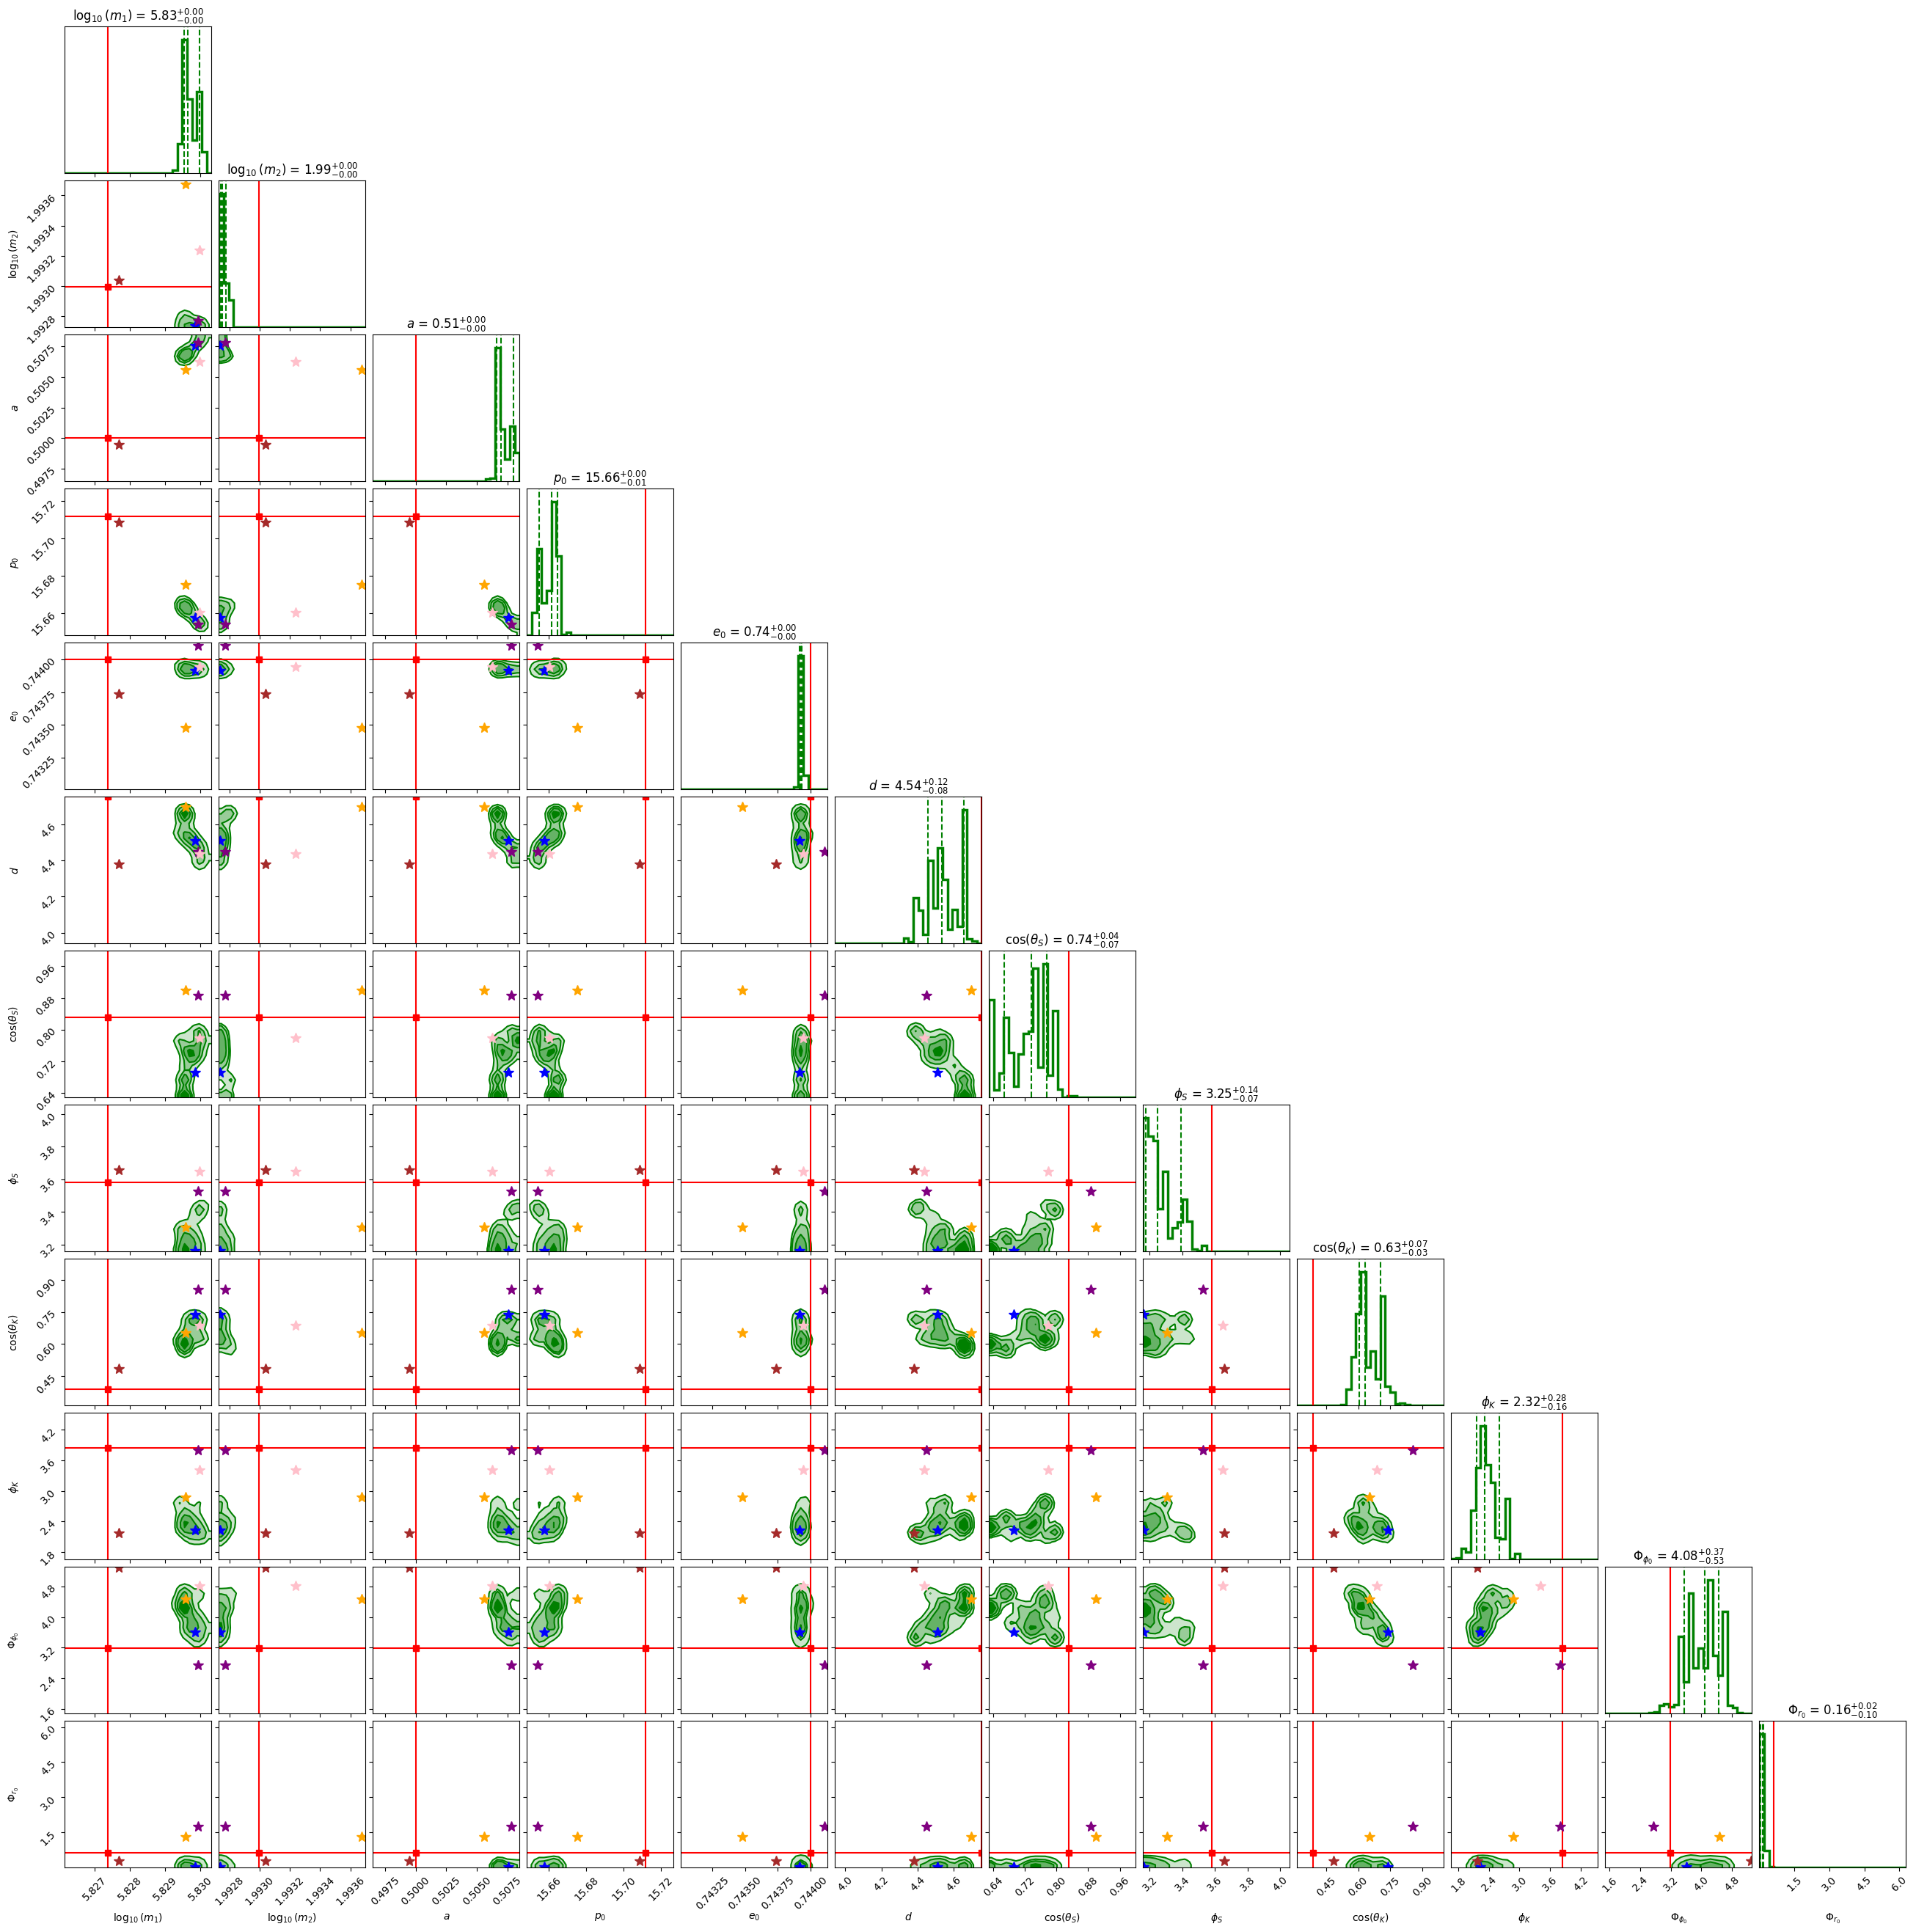

In [18]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$d$', r'$\cos(\theta_S)$', r'$\phi_S$', r'$\cos(\theta_K)$', r'$\phi_K$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1),
                       color='orange', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt3.reshape(1, -1),
                       color='purple', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt4.reshape(1, -1),
                       color='brown', marker='*', ms=10,
                       reverse=False)

corner.overplot_points(fig, maxld_pt5.reshape(1, -1),
                       color='pink', marker='*', ms=10,
                       reverse=False)

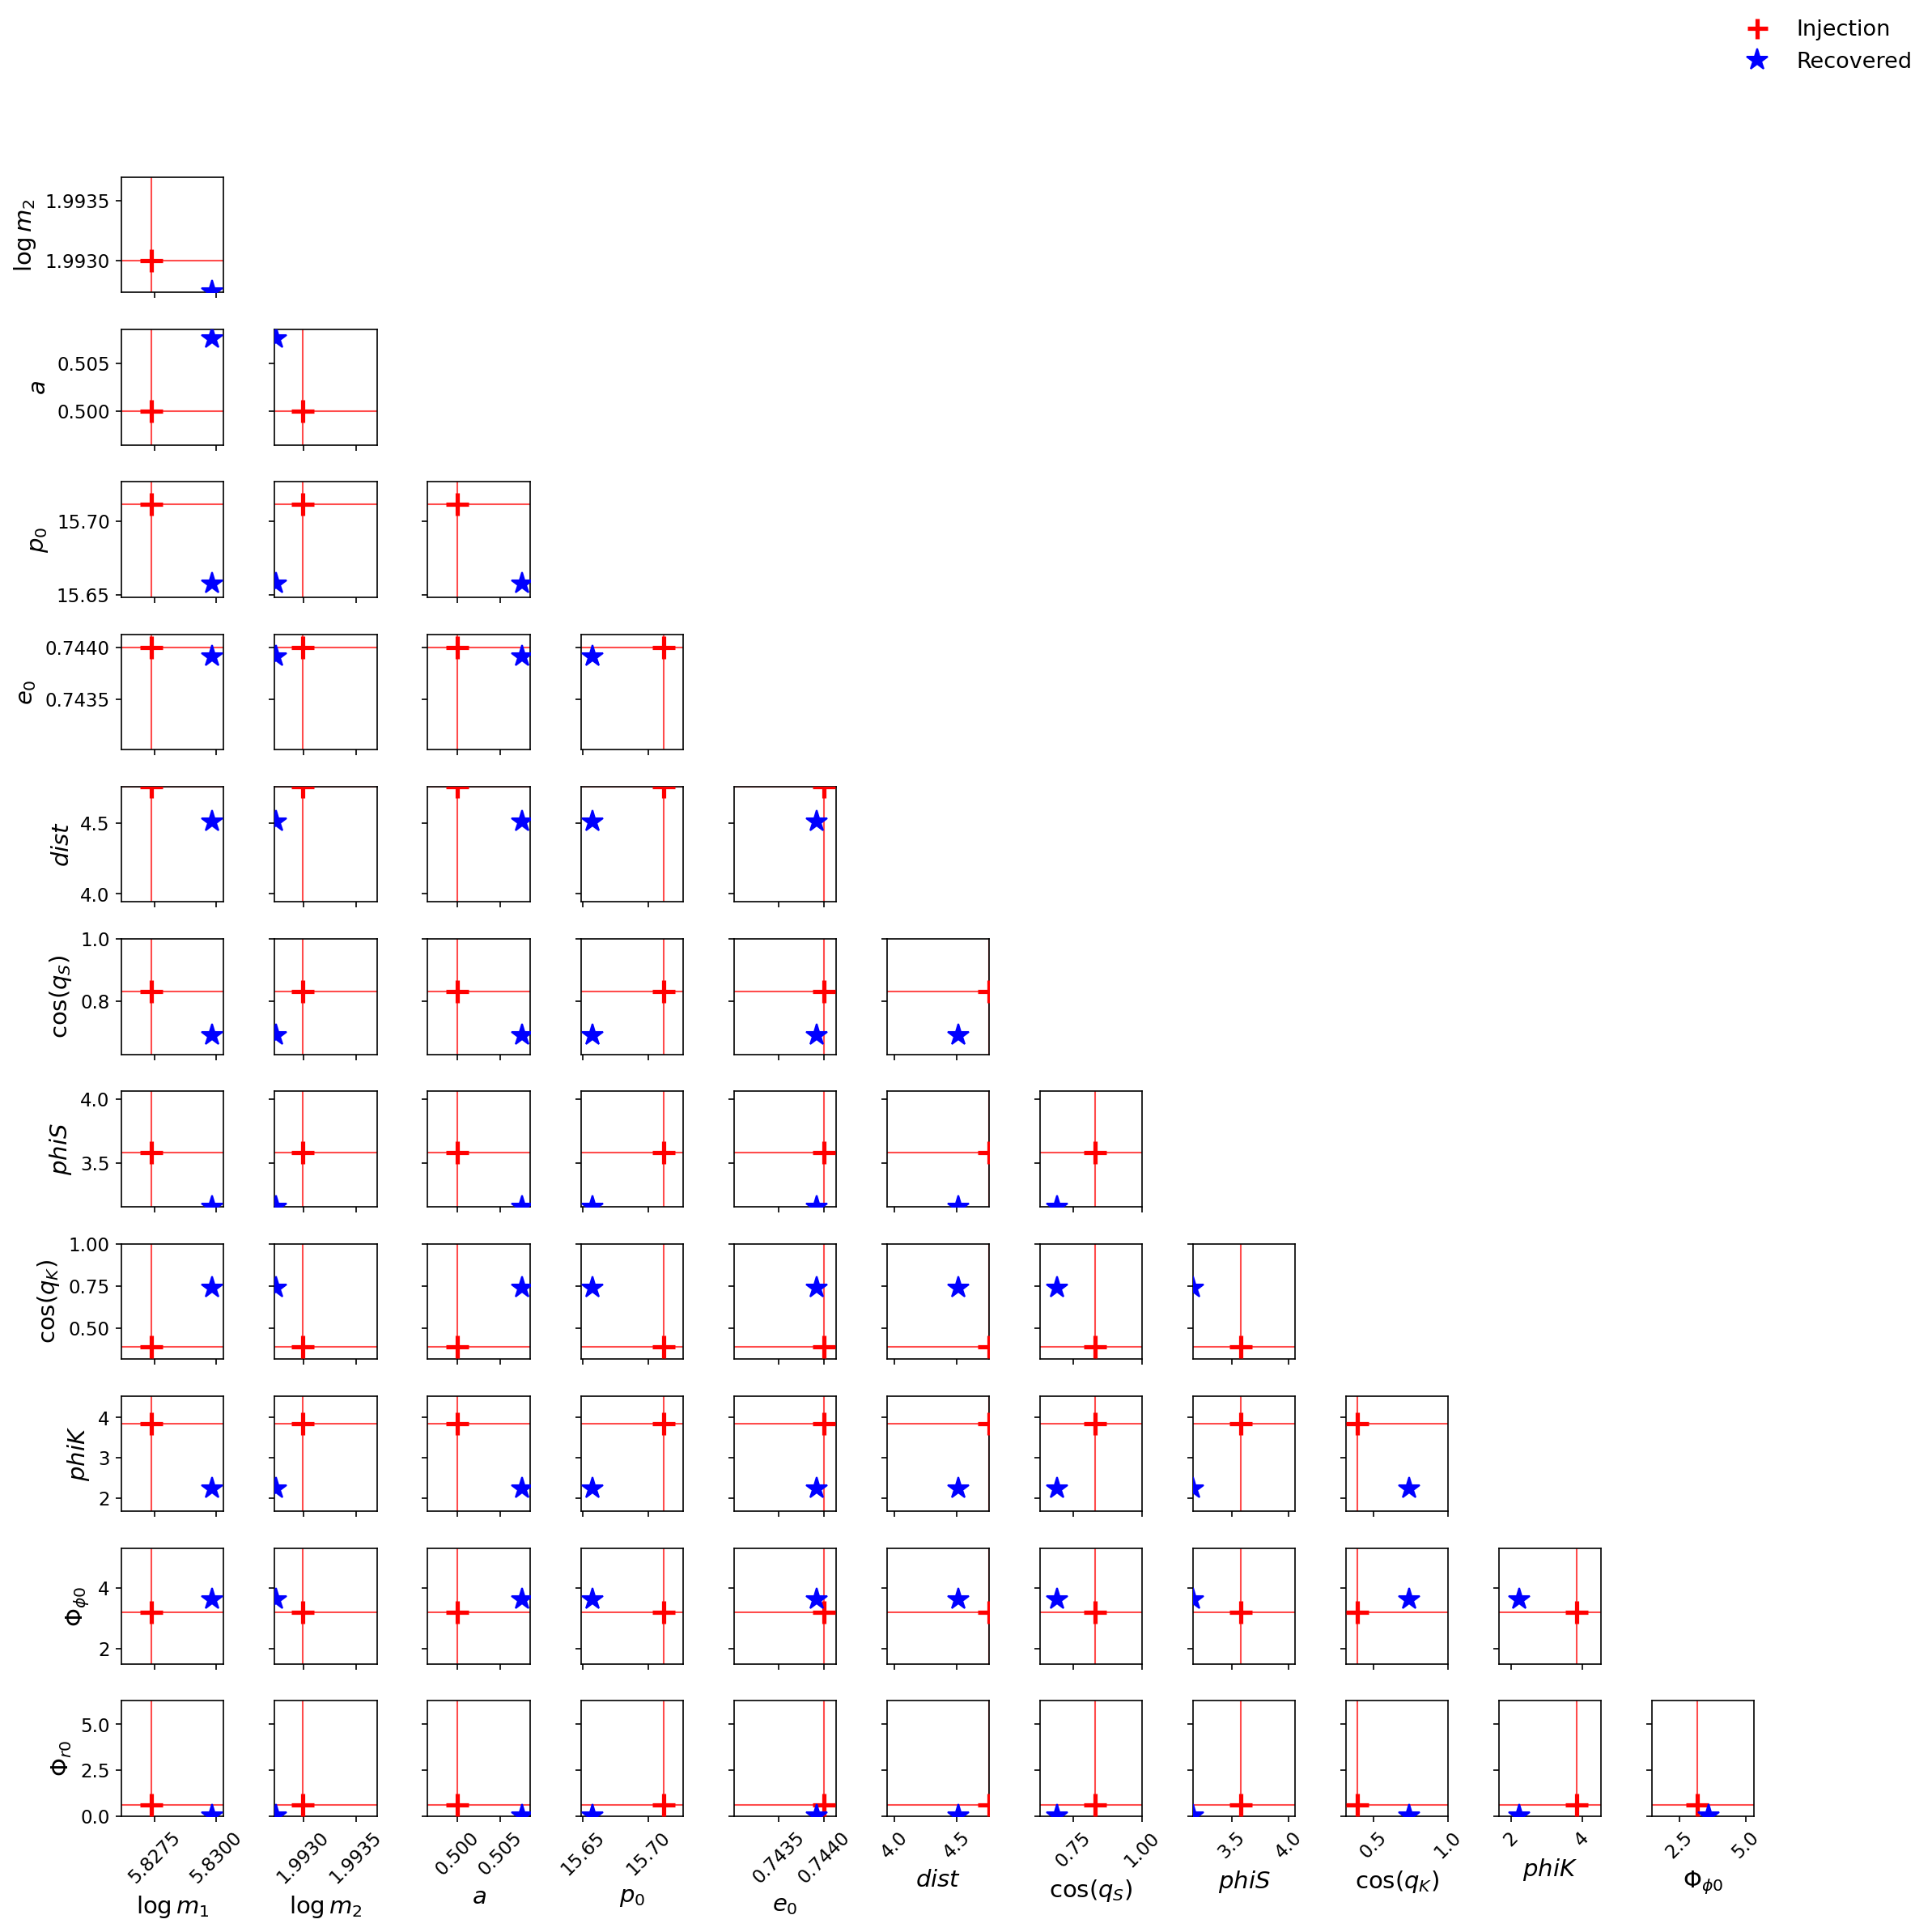

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$dist$',
          r'$\cos(q_S)$', r'$phiS$', r'$\cos(q_K)$', r'$phiK$',
          r'$\Phi_{\phi0}$', r'$\Phi_{r0}$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

# box_lo = np.array([5.82198, 1.99175, 0.49296, 15.56960, 0.74301, 3.12947,
#                     0.23714, 2.25783, -0.45227, 0.00000, 0.00000, 0.00000])
# box_hi = np.array([5.83449, 1.99468, 0.51048, 15.80540, 0.74413, 5.00000,
#                     1.00000, 4.96153,  1.00000, 6.28319, 6.28319, 6.28319])

fig, axes = plt.subplots(ndim, ndim, figsize=(16, 16))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # # box overlay
        # ax.add_patch(Rectangle(
        #     (box_lo[j], box_lo[i]),
        #     box_hi[j] - box_lo[j],
        #     box_hi[i] - box_lo[i],
        #     facecolor='none', edgecolor='green', lw=1.8, zorder=2,linestyle='--',
        # ))

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
    # Line2D([0], [0], color='green',  lw=1.8,                            label=r'Next prior box'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

# connection plot to proc 1

In [20]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82984793,  1.99274011,  0.50756501, 15.65733018,  0.74391669,
         4.50983894,  0.69192023,  3.16117295,  0.73969406,  2.23488217,
         3.61678939,  0.02628325]])

In [21]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [22]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [23]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


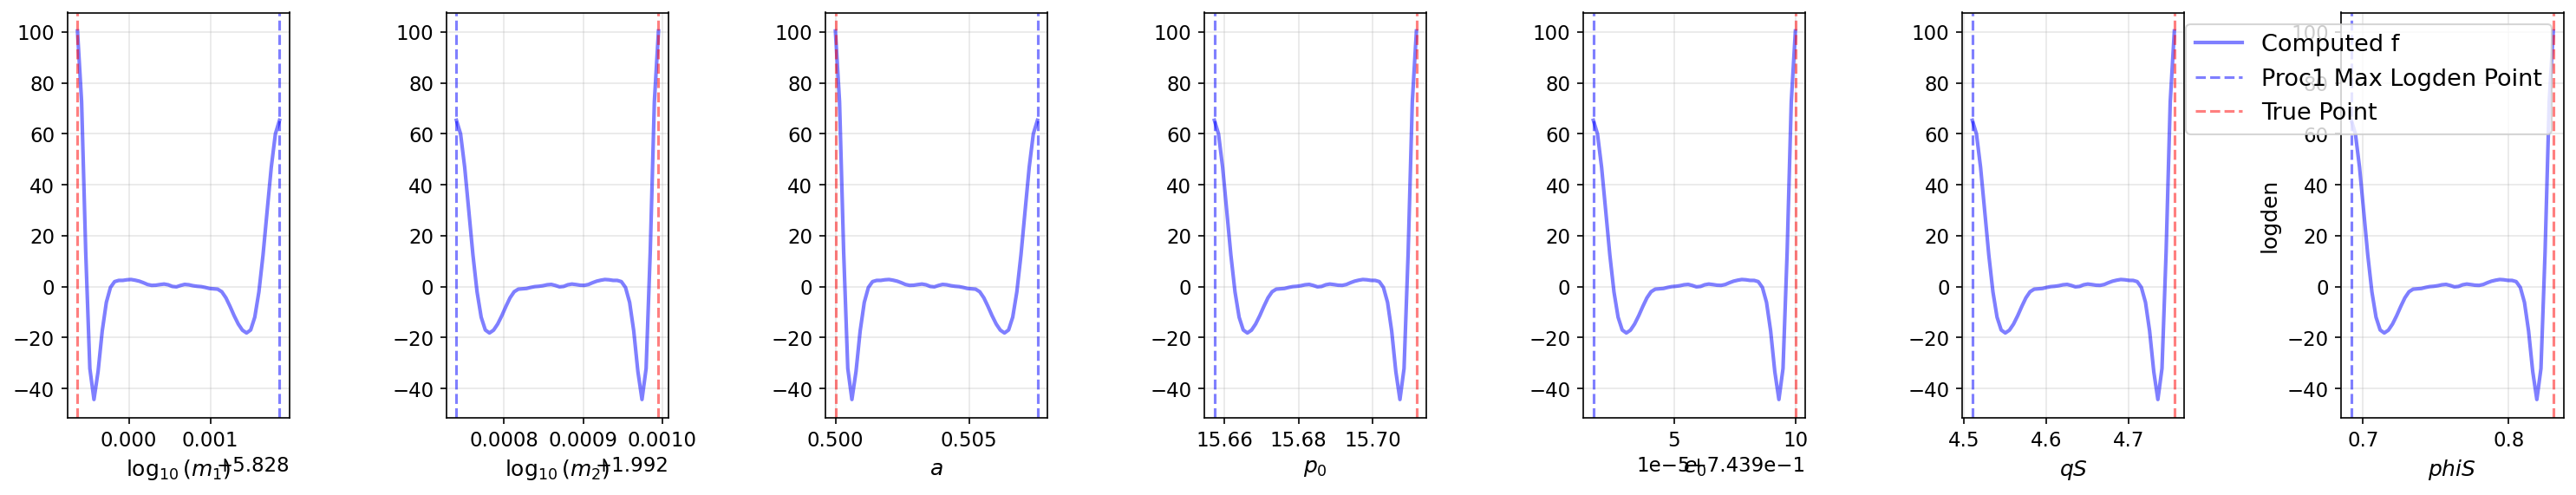

In [25]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
